<a href="https://colab.research.google.com/github/aathipatcheri54-bot/aathikesavan/blob/main/DLVEXP1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Original


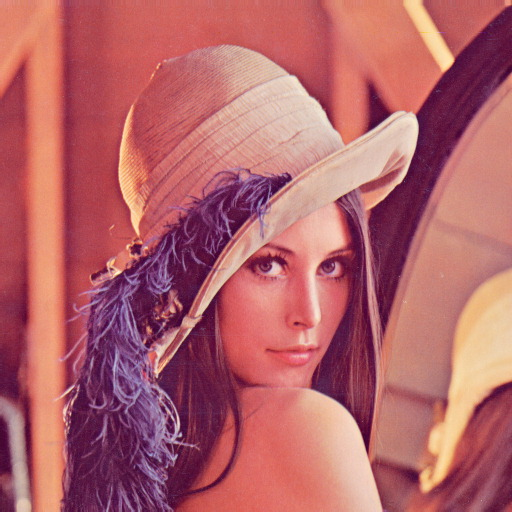

Edges


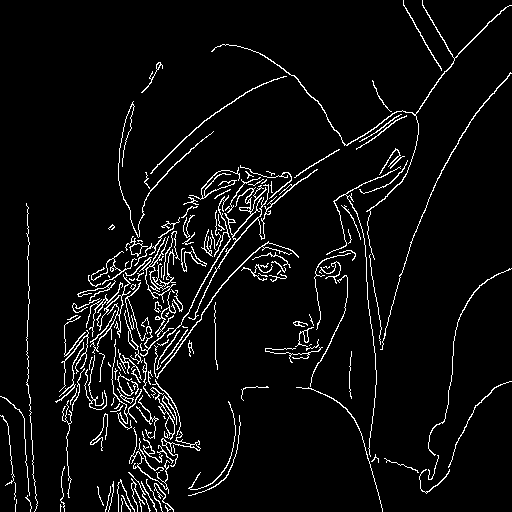

Corners


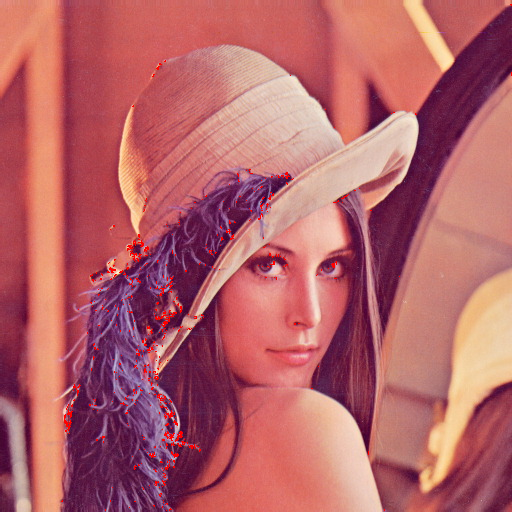

Blobs


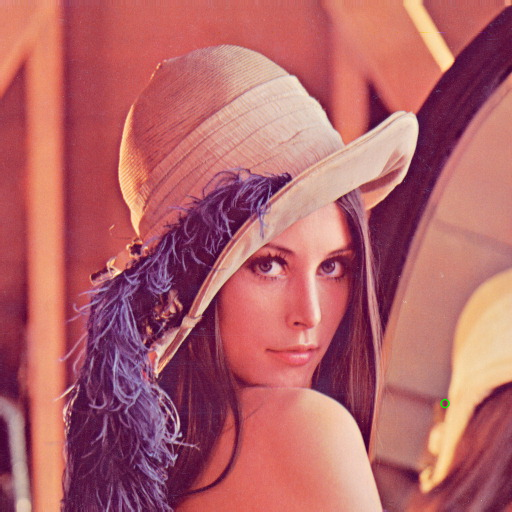

In [1]:
import cv2
import numpy as np
import os
from google.colab.patches import cv2_imshow

# Download a sample image if it doesn't exist
if not os.path.exists('sample.jpg'):
    import urllib.request
    url = 'https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg'
    urllib.request.urlretrieve(url, 'sample.jpg')

# Attempt to load the image
img = cv2.imread('sample.jpg')

if img is None:
    print("Error: Could not load 'sample.jpg'. Please ensure the file is uploaded to the session.")
else:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blur, 50, 150)
    corners = cv2.cornerHarris(np.float32(gray), 2, 3, 0.04)

    img_corners = img.copy()
    img_corners[corners > 0.01 * corners.max()] = [0, 0, 255]

    detector = cv2.SimpleBlobDetector_create()
    keypoints = detector.detect(gray)
    img_blobs = cv2.drawKeypoints(img, keypoints, None, (0, 255, 0), cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

    # Use cv2_imshow for Colab compatibility
    print("Original")
    cv2_imshow(img)
    print("Edges")
    cv2_imshow(edges)
    print("Corners")
    cv2_imshow(img_corners)
    print("Blobs")
    cv2_imshow(img_blobs)